In [1]:
import os
# Tensorflow trop bavard pour moi
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3' 
os.environ['TF_ENABLE_ONEDNN_OPTS'] = '0'
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
import yaml
import seaborn as sns
from tensorflow import keras
import glob
from tensorflow.keras.preprocessing.image import load_img, img_to_array

In [2]:
with open("configs/cat_vae_config.yaml", "r") as f:
    config = yaml.safe_load(f)

LATENT_DIM = config['model_params']['latent_dim']
SAVE_ENCODER = config['paths']['save_encoder']
SAVE_DECODER = config['paths']['save_decoder']
IMG_SIZE = 64

In [3]:
class Sampling(tf.keras.layers.Layer):
    def call(self, inputs):
        z_mean, z_log_var = inputs
        batch, dim = tf.shape(z_mean)[0], tf.shape(z_mean)[1]
        epsilon = tf.random.normal(shape=(batch, dim))
        return z_mean + tf.exp(0.5 * z_log_var) * epsilon

encoder = tf.keras.models.load_model(SAVE_ENCODER, custom_objects={'Sampling': Sampling})
decoder = tf.keras.models.load_model(SAVE_DECODER)

We load the data

In [5]:
def load_test_cats(path, n=100):
    pass 

dataset_path = "ressources/*" 
files = glob.glob(dataset_path)[:2000]

x_test = np.array([img_to_array(load_img(f, target_size=(64, 64))) / 255.0 for f in files])

Let's try to see how the latent space is. Like you can see our laws are centered but not reduced. despite a lot of dispositions in the hyperparameters I couldn't achieve a reduced latent space, however all our cats seem to be close to zero.

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


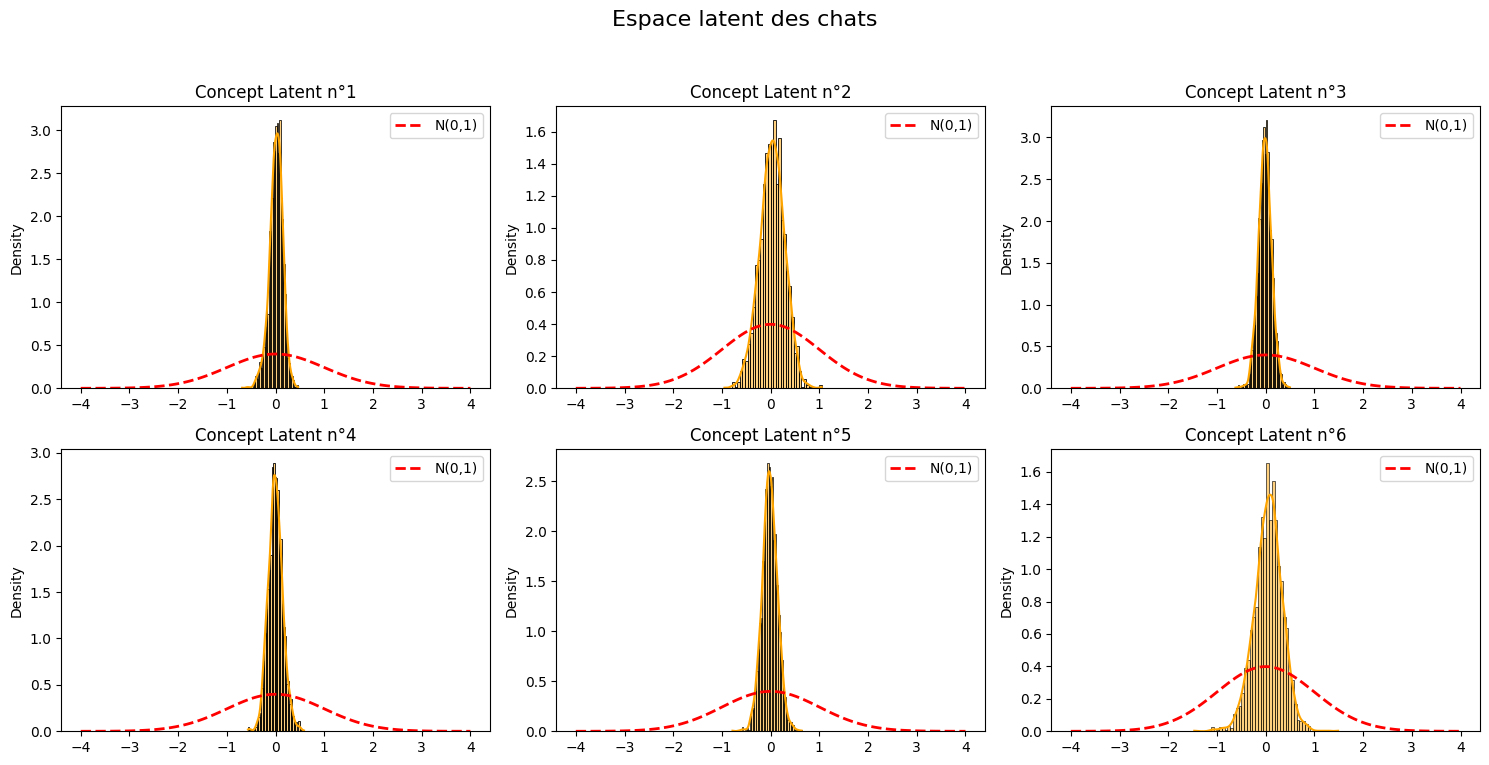

In [6]:
n_samples = min(len(x_test), 2000)
z_mean, _, _ = encoder.predict(x_test[:n_samples])

plt.figure(figsize=(15, 8))
plt.suptitle("Espace latent des chats", fontsize=16)

for i in range(6):
    plt.subplot(2, 3, i + 1)
    sns.histplot(z_mean[:, i], kde=True, color="orange", stat="density")
    x = np.linspace(-4, 4, 100)
    p = (1/np.sqrt(2*np.pi)) * np.exp(-0.5 * x**2)
    plt.plot(x, p, 'r--', lw=2, label='N(0,1)')
    plt.title(f"Concept Latent n°{i+1}")
    plt.legend()

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [ ]:
For the interpolation results are good we can see small differenes at each step

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 52ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step


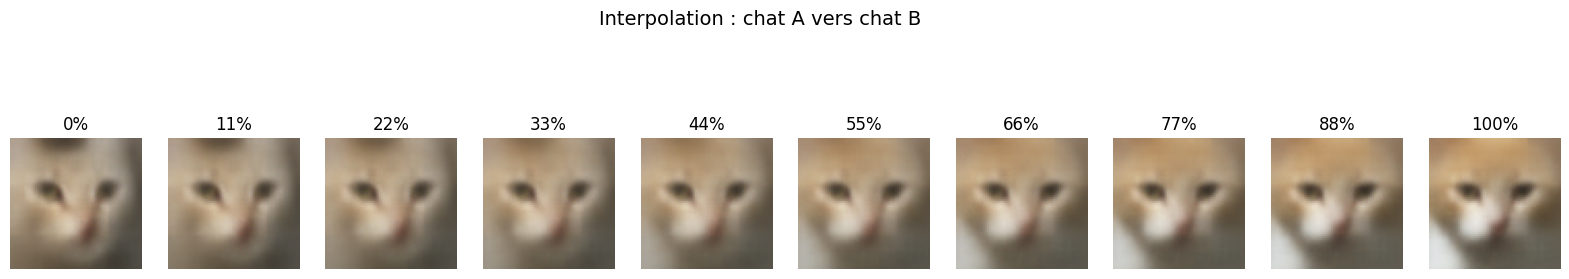

In [7]:
""" trajet entre deux chats réels """
res_A = encoder.predict(x_test[0:1])
res_B = encoder.predict(x_test[1:2])
code_A = res_A[0]
code_B = res_B[0]

steps = 10
plt.figure(figsize=(20, 4))
plt.suptitle("Interpolation : chat A vers chat B", fontsize=14)

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_A + alpha * code_B
    inter_img = decoder.predict(inter_code.reshape(1, -1))[0]
    
    plt.subplot(1, steps, i + 1)
    plt.imshow(np.clip(inter_img, 0, 1))
    plt.axis('off')
    plt.title(f"{int(alpha*100)}%")

plt.show()

Finally, for our random cat, our results are... random. We can have very good or very bad results. This may be caused by the fact that the variance of our space is very important. Thus, if our vector is far from the center, the final cat can seem weird.

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step


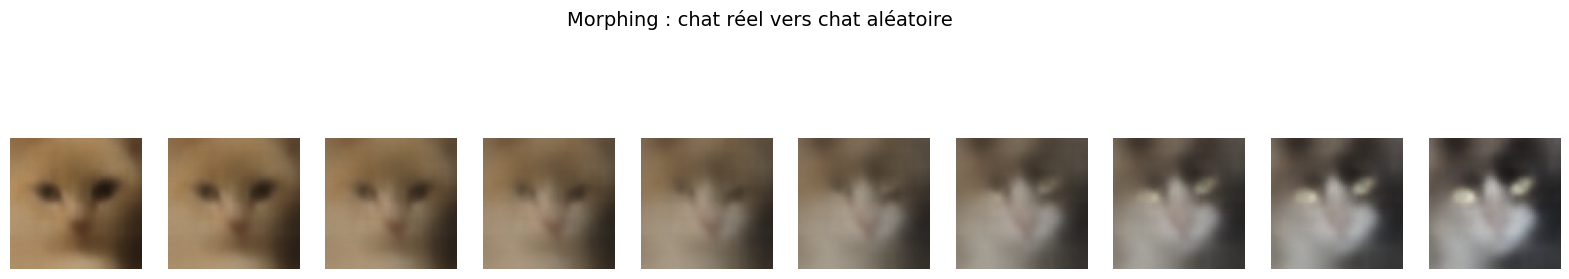

In [9]:
""" chat réel vers vecteur inconnu """
code_real = encoder.predict(x_test[2:3])[0]
code_random = np.random.normal(size=(1, LATENT_DIM))

plt.figure(figsize=(20, 4))
plt.suptitle("Morphing : chat réel vers chat aléatoire", fontsize=14)

for i in range(steps):
    alpha = i / (steps - 1)
    inter_code = (1 - alpha) * code_real + alpha * code_random
    inter_img = decoder.predict(inter_code.reshape(1, -1))[0]
    
    plt.subplot(1, steps, i + 1)
    plt.imshow(np.clip(inter_img, 0, 1))
    plt.axis('off')

plt.show()